# SLAYER with Delay Learning using SHD-Whole Dataset

In [1]:
import pickle
import random
import numpy as np
from scipy import io
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as tnnf
from tqdm.notebook import tqdm

ms = 1e-3 # use this constant so you can write e.g. 1*ms for a time

In [2]:
import sys, os
CURRENT_TEST_DIR = os.getcwd()
sys.path.append(CURRENT_TEST_DIR + "/../../src")
import slayerSNN as snn

## Begin Here to Train

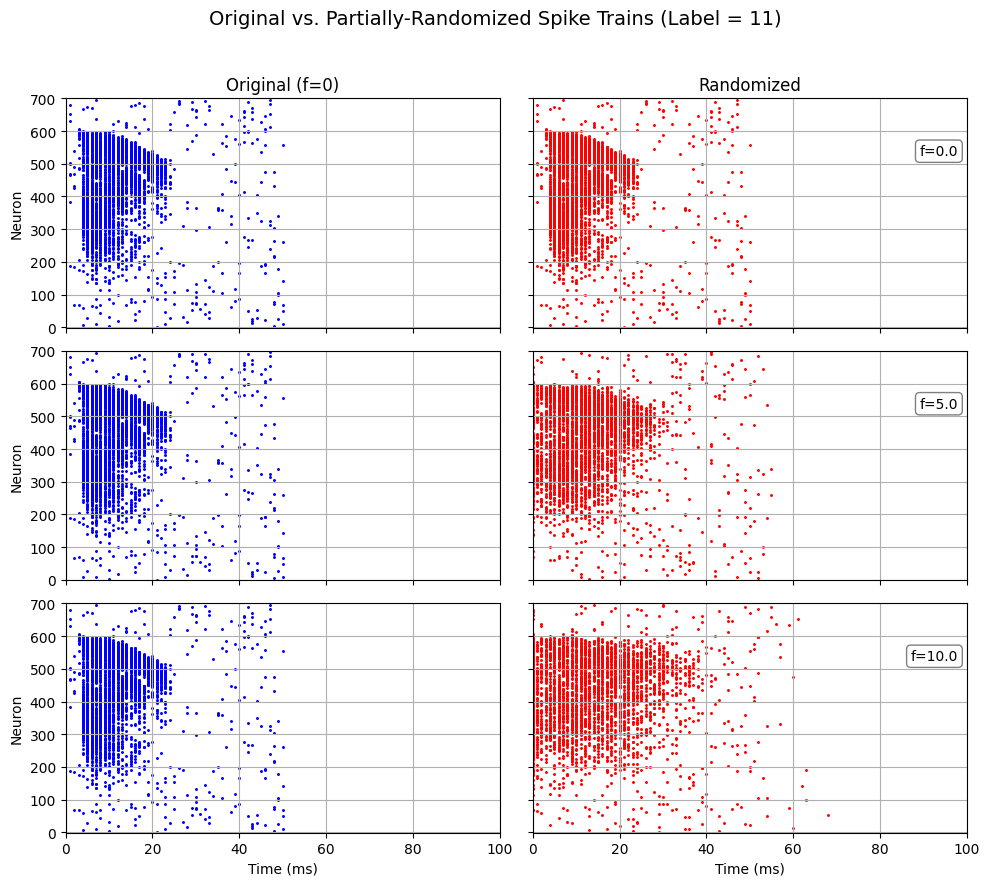

Got a batch: x_batch.shape=torch.Size([2, 700, 100]), y_batch=tensor([0, 7])


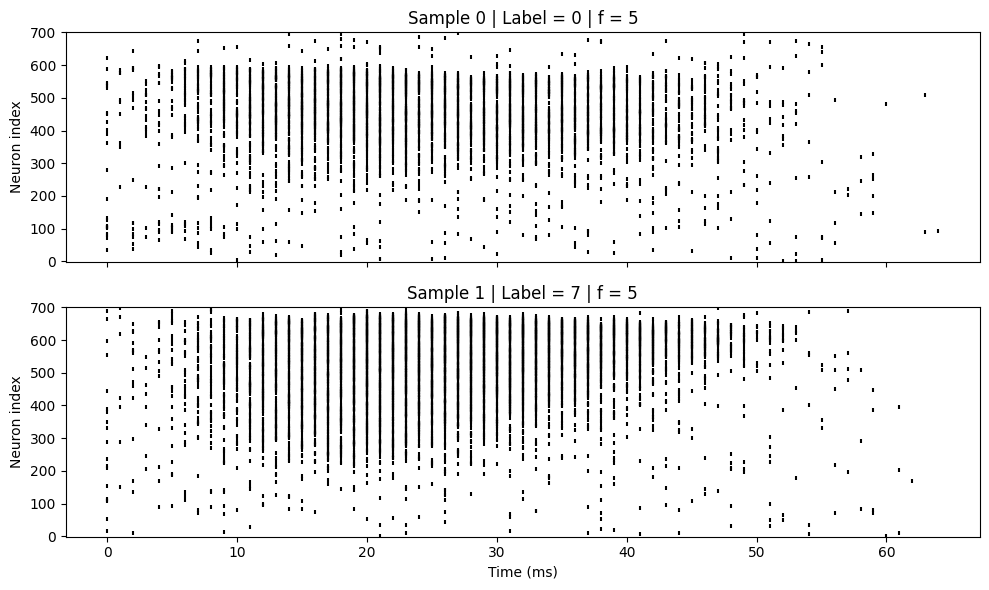

In [3]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import scipy.io as io
import matplotlib.pyplot as plt


# === Utility functions ===

def partial_randomize_spike_train(spike_train, f=1.0, max_attempts=500):
    num_neurons, T = spike_train.shape
    new_train = np.zeros_like(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        if len(spike_times) == 0:
            continue

        for old_time in spike_times:
            inserted = False
            attempts = 0
            while not inserted and attempts < max_attempts:
                attempts += 1
                jittered_time = int(round(old_time + np.random.normal(0, f)))
                jittered_time = np.clip(jittered_time, 0, T - 1)

                if new_train[neuron_idx, jittered_time] == 0:
                    new_train[neuron_idx, jittered_time] = 1
                    inserted = True

            if not inserted:
                new_train[neuron_idx, old_time] = 1

    return new_train


# === Custom Dataset ===

class SHDSpikeDataset(Dataset):
    def __init__(self, mat_path):
        data = io.loadmat(mat_path)
        X = data["X"]
        Y = data["Y"].ravel()
        self.original_shape = X.shape
        self.Y = torch.tensor(Y, dtype=torch.long)
        self.X = torch.tensor(X, dtype=torch.uint8)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


# === Visualization functions ===

def show_single_sample_different_f(spike_tensor, label, f_values=[0.0, 0.3, 0.9]):
    """
    Visualize one sample under different randomization levels (f).
    """
    spike_train = spike_tensor.numpy()
    fig, axes = plt.subplots(len(f_values), 2, figsize=(10, 3 * len(f_values)), sharex=True, sharey=True)
    fig.suptitle(f"Original vs. Partially-Randomized Spike Trains (Label = {label})", fontsize=14)

    for row_i, f_ in enumerate(f_values):
        ax_left = axes[row_i, 0]
        for neuron_idx in range(spike_train.shape[0]):
            spike_times = np.where(spike_train[neuron_idx] == 1)[0]
            ax_left.scatter(spike_times, np.ones_like(spike_times)*neuron_idx, s=5, color='b', marker='.')
        if row_i == 0:
            ax_left.set_title("Original (f=0)")
        ax_left.set_ylabel('Neuron')
        ax_left.grid(True)

        ax_right = axes[row_i, 1]
        randomized = partial_randomize_spike_train(spike_train, f_)
        for neuron_idx in range(randomized.shape[0]):
            spike_times = np.where(randomized[neuron_idx] == 1)[0]
            ax_right.scatter(spike_times, np.ones_like(spike_times)*neuron_idx, s=5, color='r', marker='.')
        if row_i == 0:
            ax_right.set_title("Randomized")
        ax_right.text(0.98, 0.8, f"f={f_:.1f}", transform=ax_right.transAxes,
                      ha='right', va='top', fontsize=10,
                      bbox=dict(boxstyle="round", fc="white", ec="gray"))
        ax_right.grid(True)

        for ax in (ax_left, ax_right):
            ax.set_ylim([-1, spike_train.shape[0]])
            ax.set_xlim([0, spike_train.shape[1]])

    axes[-1, 0].set_xlabel('Time (ms)')
    axes[-1, 1].set_xlabel('Time (ms)')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def demo_batch_visualization(loader, f=0.3):
    """
    Visualize a batch of spike samples after optional randomization.
    """
    x_batch, y_batch = next(iter(loader))
    batch_size = len(y_batch)
    print(f"Got a batch: x_batch.shape={x_batch.shape}, y_batch={y_batch}")

    fig, axes = plt.subplots(batch_size, 1, figsize=(10, 3 * batch_size), sharex=True, sharey=True)
    if batch_size == 1:
        axes = [axes]

    for i in range(batch_size):
        spike_mat = x_batch[i].numpy()
        spike_mat = partial_randomize_spike_train(spike_mat, f)
        ax = axes[i]
        for neuron_idx in range(spike_mat.shape[0]):
            spike_times = np.where(spike_mat[neuron_idx] == 1)[0]
            ax.scatter(spike_times, np.ones_like(spike_times) * neuron_idx,
                       s=5, marker='|', color='black')
        ax.set_title(f"Sample {i} | Label = {y_batch[i].item()} | f = {f}")
        ax.set_ylabel("Neuron index")
        ax.set_ylim([-1, spike_mat.shape[0]])
    axes[-1].set_xlabel("Time (ms)")
    plt.tight_layout()
    plt.show()


# === Load dataset and visualize ===

dataset = SHDSpikeDataset("shd_whole.mat")
loader = DataLoader(dataset, batch_size=2, shuffle=True)

# Visualize one sample
show_single_sample_different_f(dataset[0][0], dataset[0][1], f_values=[0,5,10])

# Visualize one batch
demo_batch_visualization(loader, f=5)

## Build the Spiking Neural Network Model (SNN)

In [10]:
import os, numpy as np, torch, torch.nn as nn, slayerSNN as snn
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.io import loadmat
from torch.utils.data import Dataset, DataLoader

# === Load and pad data ===
data = loadmat("shd_whole.mat")
X = data["X"]  # shape: (samples, neurons, 100)
Y = data["Y"].ravel()
num_neurons, T = X.shape[1], X.shape[2]
num_classes = len(np.unique(Y))
T_ori = T
T_target = 200
if T < T_target:
    padded = np.zeros((X.shape[0], num_neurons, T_target), dtype=X.dtype)
    padded[:, :, :T] = X
    X = padded
    T = T_target
    print(f"Padded X from {T_ori} to {T_target} time steps.")

print(f"X shape after padding: {X.shape}")

# === SNN parameters ===
sim_param = dict(Ts=1, tSample=200)
lif_param = dict(type='SRMALPHA', theta=10, tauSr=1, tauRho=0.1, tauRef=2, scaleRef=2, scaleRho=0.1)

training_range   = (0.0, 0.6)
validation_range = (0.6, 0.75)
testing_range    = (0.75, 0.9)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Partial randomization ===
def partial_randomize_spike_train(spike_train, f=1.0, max_attempts=50):
    num_neurons, T = spike_train.shape
    new_train = np.zeros_like(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        if len(spike_times) == 0:
            continue

        for old_time in spike_times:
            inserted = False
            attempts = 0
            while not inserted and attempts < max_attempts:
                attempts += 1
                jittered_time = int(round(old_time + np.random.normal(0, f)))
                jittered_time = np.clip(jittered_time, 0, T - 1)

                if new_train[neuron_idx, jittered_time] == 0:
                    new_train[neuron_idx, jittered_time] = 1
                    inserted = True

            if not inserted:
                new_train[neuron_idx, old_time] = 1

    return new_train

# === Dataset wrapper ===
class SpikeTensorDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.Y[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

# === DataLoader preprocessing ===
def preprocess_full_dataset_dataloader(X, Y, f, batch_size=128, seed=42):
    np.random.seed(seed)
    N = len(Y)
    train_start, train_end = training_range
    val_start, val_end = validation_range
    test_start, test_end = testing_range

    train_indices = np.arange(int(N * train_start), int(N * train_end))
    val_indices   = np.arange(int(N * val_start), int(N * val_end))
    test_indices  = np.arange(int(N * test_start), int(N * test_end))

    np.random.shuffle(train_indices)

    # === 先批量扰动，存静态 X ===
    print(f"Applying partial_randomize_spike_train with f={f} to train/val/test set...")
    X_train_proc = np.array([partial_randomize_spike_train(X[i], f) for i in train_indices])
    X_val_proc   = np.array([partial_randomize_spike_train(X[i], f) for i in val_indices])
    X_test_proc  = np.array([partial_randomize_spike_train(X[i], f) for i in test_indices])

    Y_train = Y[train_indices]
    Y_val   = Y[val_indices]
    Y_test  = Y[test_indices]

    train_ds = SpikeTensorDataset(X_train_proc, Y_train)
    val_ds   = SpikeTensorDataset(X_val_proc, Y_val)
    test_ds  = SpikeTensorDataset(X_test_proc, Y_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

# === Network ===
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        slayer = snn.layer(lif_param, sim_param)
        self.slayer = slayer
        self.fc1 = nn.utils.weight_norm(slayer.dense(700, 128), name='weight')
        self.fc2 = nn.utils.weight_norm(slayer.dense(128, 128), name='weight')
        self.fc3 = nn.utils.weight_norm(slayer.dense(128, 20), name='weight')
        self.delay1 = slayer.delay(128)
        self.delay2 = slayer.delay(128)

    def forward(self, x):
        if isinstance(x, np.ndarray): x = torch.from_numpy(x)
        if x.dim() == 3: x = x.unsqueeze(2).unsqueeze(3)
        x = x.float().to(device)
        x = self.slayer.spike(self.fc1(self.slayer.psp(x)))
        x = self.delay1(x)
        x = self.slayer.spike(self.fc2(self.slayer.psp(x)))
        x = self.delay2(x)
        x = self.slayer.spike(self.fc3(self.slayer.psp(x)))
        return x

    def clamp(self, thea1, thea2):
        self.delay1.delay.data.clamp_(0, thea1)
        self.delay2.delay.data.clamp_(0, thea2)

# === Train ===
def train_model(train_loader, val_loader, f=0.0, epochs=100, lr=0.1, seed=42):
    from slayerSNN import spikeLoss, utils
    import random
    import torch.backends.cudnn as cudnn

    def set_seed(seed):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            cudnn.benchmark = False
            cudnn.deterministic = True
            cudnn.enabled = False

    set_seed(seed)
    net = Network().to(device)

    error_cfg = {
        'neuron': lif_param,
        'simulation': sim_param,
        'training': {
            'error': {
                'type': 'SpikeRate',
                'tgtSpikeRegion': {'start': 0, 'stop': 200},
                'tgtSpikeRate': {True: 0.2, False: 0.02}
            }
        }
    }
    loss_fn = spikeLoss.spikeLoss(error_cfg).to(device)
    optimizer = utils.optim.Nadam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[300], gamma=0.1)

    best_val = float('inf')
    best_state = None
    loss_log, val_log = [], []
    update1 = update2 = 0
    thea1 = thea2 = 64
    early_stop_counter = 0
    early_stop_patience = 300

    from math import ceil
    
    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps) as pbar:
        for epoch in range(epochs):
            net.train()
            batch_losses = []

            for xb, yb in train_loader:
                x = xb.unsqueeze(2).unsqueeze(3).float().to(device)
                y = yb.long().to(device)
                target = torch.zeros((len(y), num_classes, 1, 1, 1), device=device)
                target.scatter_(1, y[:, None, None, None, None], 1.0)

                out = net(x)
                loss = loss_fn.spikeRate(out, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                batch_losses.append(loss.item())
                pbar.update(1)

            # Clamp delay
            if epoch <= 250:
                net.clamp(64, 64)
            else:
                update1 += 1; update2 += 1
                for name, param in net.named_parameters():
                    if "delay1.delay" in name and update1 > 150:
                        sorted_ = torch.sort(torch.floor(param.detach().flatten()))[0]
                        thea1 = torch.max(sorted_)
                        if sorted_[108] > (thea1 - 5):
                            thea1 += 1
                            update1 = 0
                            #print(f"Updated delay1 to {thea1}")
                    elif "delay2.delay" in name and update2 > 150:
                        sorted_ = torch.sort(torch.floor(param.detach().flatten()))[0]
                        thea2 = torch.max(sorted_)
                        if sorted_[108] > (thea2 - 5):
                            thea2 += 1
                            update2 = 0
                            #print(f"Updated delay2 to {thea2}")
                net.clamp(thea1, thea2)

            net.eval(); val_loss = 0; correct = total = 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    x = xb.unsqueeze(2).unsqueeze(3).float().to(device)
                    y = yb.long().to(device)
                    target = torch.zeros((len(y), num_classes, 1, 1, 1), device=device)
                    target.scatter_(1, y[:, None, None, None, None], 1.0)
                    out = net(x)
                    val_loss += loss_fn.spikeRate(out, target).item()
                    pred = snn.predict.getClass(out)
                    correct += (pred.cpu() == y.cpu()).sum().item()
                    total += len(y)

            val_loss /= max(1, len(val_loader))
            val_acc = correct / total
            loss_log.append(np.mean(batch_losses))
            val_log.append(val_loss)

            if val_loss < best_val:
                best_val = val_loss
                best_state = net.state_dict()
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= early_stop_patience:
                    print(f"Early stopped at epoch {epoch+1} (val_loss={val_loss:.4f})")
                    break

            pbar.set_postfix_str(
                f"Ep {epoch+1} | Train {loss_log[-1]:.3f} | Val {val_loss:.3f} | Val Acc {val_acc:.2%}"
            )
            scheduler.step()

    if best_state: net.load_state_dict(best_state)
    plt.figure()
    plt.semilogy(loss_log, label='Train Loss')
    plt.semilogy(val_log, label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.title("Train vs. Val Loss"); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()
    return net

def test_accuracy_cached_dataloader(net, test_loader):
    net.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            x = xb.unsqueeze(2).unsqueeze(3).float().to(device)
            pred = snn.predict.getClass(net(x))
            correct += (pred.cpu().numpy() == yb.numpy()).sum()
            total += len(yb)
    return correct / total


Padded X from 100 to 200 time steps.
X shape after padding: (9984, 700, 200)


/root/miniconda3/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")



Preprocessing for f = 1
Training for f = 1


  0%|          | 0/47000 [00:00<?, ?it/s]/root/miniconda3/lib/python3.10/site-packages/slayerSNN-0.0.0-py3.10.egg/slayerSNN/optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha) (Triggered internally at ../torch/csrc/utils/python_arg_parser.cpp:1519.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
100%|██████████| 47000/47000 [2:54:21<00:00,  4.49it/s, Ep 1000 | Train 112.293 | Val 124.124 | Val Acc 92.92%] 


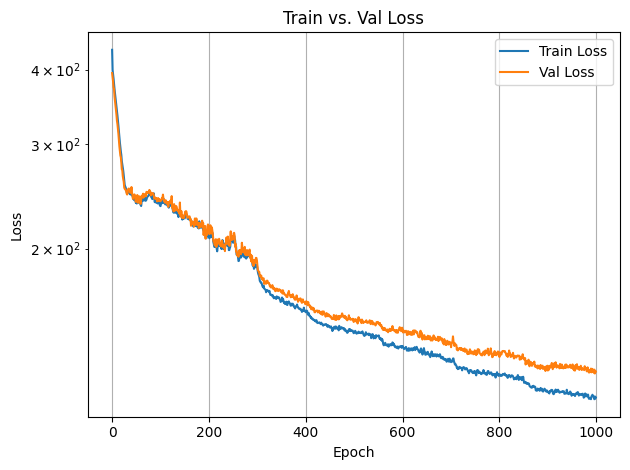

Saved slayer_jitter_whole_f1.pt | Test Accuracy: 86.57%


In [11]:
f_values = [1]

for f in f_values:
    print(f"\nPreprocessing for f = {f}")
    #train_loader, val_loader, test_loader = preprocess_full_dataset_dataloader(X, Y, f=f, batch_size=128, seed=42)

    print(f"Training for f = {f}")
    net = train_model(train_loader, val_loader, f=f, epochs=1000)

    model_path = f"slayer_jitter_whole_f{int(f)}.pt"
    torch.save(net.state_dict(), model_path)

    acc = test_accuracy_cached_dataloader(net, test_loader)
    print(f"Saved {model_path} | Test Accuracy: {acc:.2%}")


Preprocessing for f = 5
Applying partial_randomize_spike_train with f=5 to train/val/test set...
Training for f = 5


100%|██████████| 47000/47000 [1:22:46<00:00,  9.46it/s, Ep 1000 | Train 139.604 | Val 153.929 | Val Acc 87.05%]


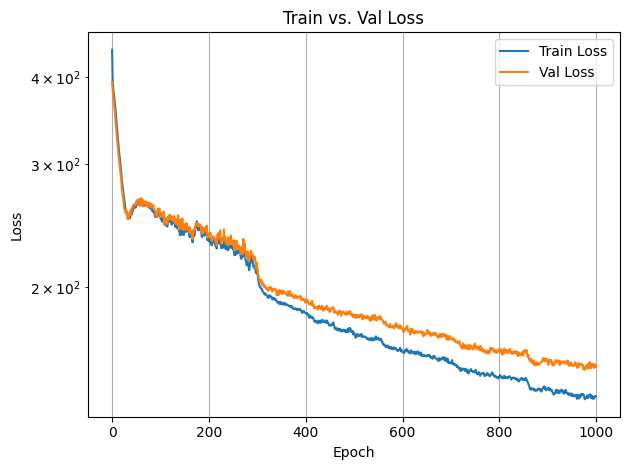

Saved slayer_jitter_whole_f5.pt | Test Accuracy: 80.43%

Preprocessing for f = 10
Applying partial_randomize_spike_train with f=10 to train/val/test set...
Training for f = 10


100%|██████████| 47000/47000 [1:03:47<00:00, 12.28it/s, Ep 1000 | Train 165.986 | Val 180.188 | Val Acc 81.44%]


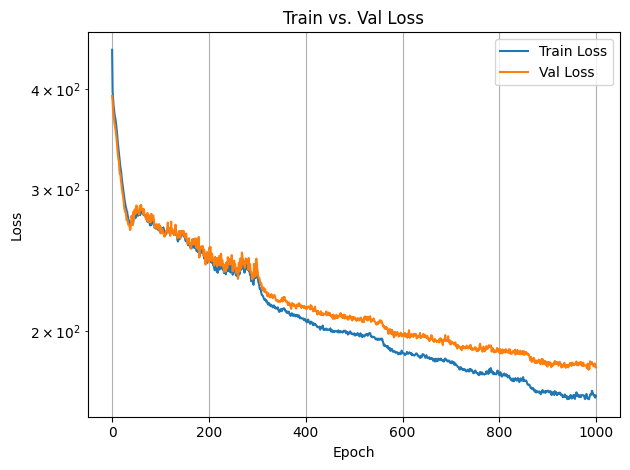

Saved slayer_jitter_whole_f10.pt | Test Accuracy: 71.28%

Preprocessing for f = 20
Applying partial_randomize_spike_train with f=20 to train/val/test set...
Training for f = 20


100%|██████████| 47000/47000 [1:02:28<00:00, 12.54it/s, Ep 1000 | Train 165.489 | Val 186.617 | Val Acc 75.03%]


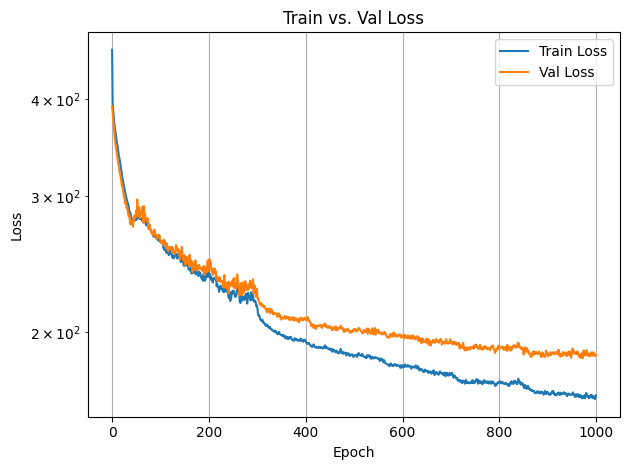

Saved slayer_jitter_whole_f20.pt | Test Accuracy: 64.60%

Preprocessing for f = 25
Applying partial_randomize_spike_train with f=25 to train/val/test set...
Training for f = 25


100%|██████████| 47000/47000 [1:02:24<00:00, 12.55it/s, Ep 1000 | Train 179.513 | Val 198.924 | Val Acc 72.83%]


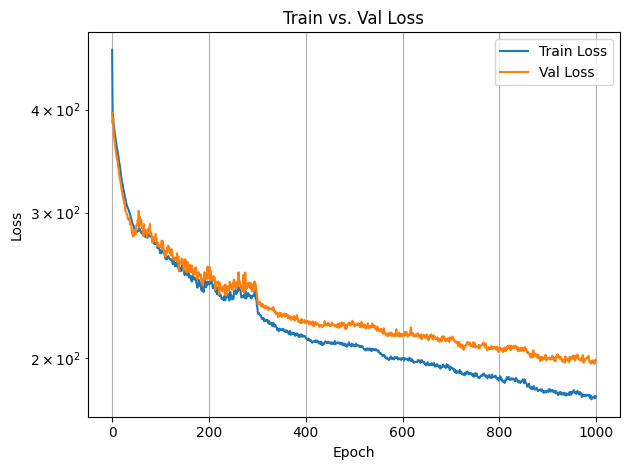

Saved slayer_jitter_whole_f25.pt | Test Accuracy: 64.20%

Preprocessing for f = 30
Applying partial_randomize_spike_train with f=30 to train/val/test set...
Training for f = 30


 48%|████▊     | 22654/47000 [1:02:31<1:14:10,  5.47it/s, Ep 481 | Train 216.670 | Val 225.979 | Val Acc 66.42%]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

100%|██████████| 47000/47000 [2:10:46<00:00,  5.99it/s, Ep 1000 | Train 194.428 | Val 209.553 | Val Acc 69.96%] 


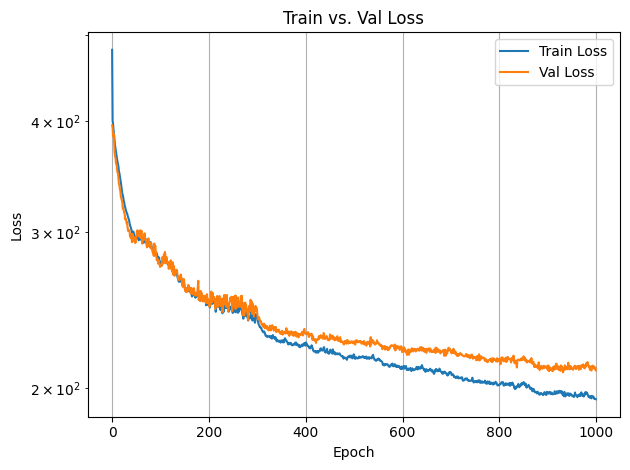

Saved slayer_jitter_whole_f30.pt | Test Accuracy: 60.79%


In [12]:
f_values = [5, 10, 20, 25, 30]

for f in f_values:
    print(f"\nPreprocessing for f = {f}")
    train_loader, val_loader, test_loader = preprocess_full_dataset_dataloader(X, Y, f=f, batch_size=128, seed=42)

    print(f"Training for f = {f}")
    net = train_model(train_loader, val_loader, f=f, epochs=1000)

    model_path = f"slayer_jitter_whole_f{int(f)}.pt"
    torch.save(net.state_dict(), model_path)

    acc = test_accuracy_cached_dataloader(net, test_loader)
    print(f"Saved {model_path} | Test Accuracy: {acc:.2%}")

## Evaluation

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# === Settings ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
f_values = [1, 5, 10, 20, 25, 30]
repeats = 3
print(f"Using device: {device}")

# === Repeated test wrapper ===
def test_accuracy_repeats_dataloader(net, repeats, f, X, Y):
    acc_list = []
    for _ in range(repeats):
        _, _, test_loader = preprocess_full_dataset_dataloader(X, Y, f=f, batch_size=256, seed=np.random.randint(0, 10000))

        acc = test_accuracy_cached_dataloader(net, test_loader)
        acc_list.append(acc)
    return acc_list

# === Results Container ===
all_means = []
all_stds = []

# === Load X/Y once ===
data = loadmat("shd_whole.mat")
X = data["X"]  # shape: (samples, neurons, 100)
Y = data["Y"].ravel()
num_neurons, T = X.shape[1], X.shape[2]
num_classes = len(np.unique(Y))
T_ori = T
T_target = 200
if T < T_target:
    padded = np.zeros((X.shape[0], num_neurons, T_target), dtype=X.dtype)
    padded[:, :, :T] = X
    X = padded
    T = T_target
    print(f"Padded X from {T_ori} to {T_target} time steps.")

print(f"X shape after padding: {X.shape}")

# === Loop over f-values ===
for f in f_values:
    model_path = f"slayer_jitter_whole_f{int(f)}.pt"
    print(f"\n=== Loading model {model_path} and testing (f={f:.1f}) ===")
    
    net = Network().to(device)
    net.load_state_dict(torch.load(model_path, map_location=device))
    net.eval()

    acc_list = test_accuracy_repeats_dataloader(net, repeats=repeats, f=f, X=X, Y=Y)
    mean_acc = np.mean(acc_list)
    std_acc = np.std(acc_list)

    all_means.append(mean_acc)
    all_stds.append(std_acc)

    print(f"f={f:.1f} | Mean Acc: {mean_acc:.2%} | Std: {std_acc:.2%} over {repeats} runs")

# === Plot ===
plt.figure(figsize=(6, 4))
means_pct = [m * 100 for m in all_means]
stds_pct  = [s * 100 for s in all_stds]

plt.errorbar(f_values, means_pct, yerr=stds_pct,
             fmt='-o', color='blue', ecolor='red', capsize=3,
             label='Test Accuracy (%)')

plt.xlabel("Randomization level f")
plt.ylabel("Test Accuracy (%)")
plt.title(f"Robustness of SLAYER SNN (repeats={repeats})")
plt.grid(True)
plt.xticks(f_values)
plt.legend()
plt.tight_layout()
plt.show()
